<a href="https://colab.research.google.com/github/SUDIPTO2023/CVPR_Mid_Assignment/blob/main/CNN_23_50622_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Import Libraries**

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


#**Load and Explore Dataset**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


#**Data Preprocessing & Augmentation**

The input images are resized to 128×128 pixels to match the model’s input size. Data augmentation techniques such as random horizontal flipping, random rotation (±20 degrees), and color jitter are applied to the training data to increase variability and improve generalization. These transformations help the model become more robust to different image conditions. The validation data is only resized and converted to tensors to ensure consistent evaluation without augmentation. The dataset is loaded using PyTorch’s ImageFolder for both training and testing directories.

In [ ]:
import torchvision.transforms as transforms
size = 128
train_transform = transforms.Compose([
    transforms.Resize((size, size)),        # resize to model input size
    transforms.RandomHorizontalFlip(),    # horizontal flip augmentation
    transforms.RandomRotation(20),        # rotate ±20 degrees
    transforms.ColorJitter(brightness=0.15, contrast=0.2, saturation=0.15),
    transforms.ToTensor()                # convert PIL → tensor [0,1]
])

val_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
])

train_folder = '/kaggle/input/brain-tumor-mri-dataset/Training'
test_folder  = '/kaggle/input/brain-tumor-mri-dataset/Testing'

train_data = datasets.ImageFolder(train_folder,transform = train_transform)
test_data = datasets.ImageFolder(test_folder,transform = val_transform)

###Sample of Training Image

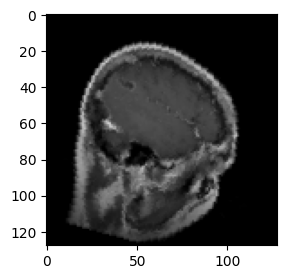

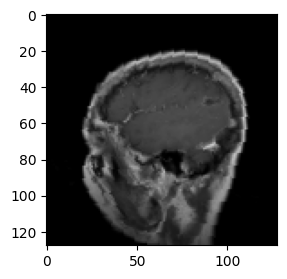

In [ ]:
plt.figure(figsize = (3,3))
plt.imshow(train_data[900][0].permute(1,2,0))
plt.figure(figsize = (3,3))
plt.imshow(train_data[800][0].permute(1,2,0))

#**Hyper Parameters Tuning**

The model was trained with a batch size of 32, a learning rate of 0.001, and a minimum learning rate of 0.0001 using a learning rate scheduler. The training was performed for 50 epochs to ensure sufficient learning and convergence.

In [ ]:
batch_size = 32
learning_rate=1e-3
minimum_learning_rate=1e-4
epochs = 50

In [ ]:
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,num_workers=2, pin_memory=True)
val_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

#**Prepare CNN Architecture**

A custom Convolutional Neural Network (CNN) was designed for multi-class image classification. The model consists of three convolutional blocks with increasing filter sizes (48 -> 96 -> 192) to progressively extract deeper features. Each block includes convolution layers followed by batch normalization and ReLU activation to improve training stability and performance. Max pooling is used for downsampling, and dropout is applied to reduce overfitting.

The classifier section uses fully connected layers with sizes 256 and 64, along with batch normalization and dropout for regularization. Finally, a fully connected layer outputs predictions for 4 classes.

The model is trained using the Adam optimizer with a learning rate of 0.001. A cosine annealing learning rate scheduler is applied to gradually reduce the learning rate to a minimum value of 0.0001. Cross entropy loss is used as the objective function for multi-class classification.

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Feature extraction layers
        self.features = nn.Sequential(
            nn.Conv2d(3, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
            nn.Conv2d(48, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            nn.Conv2d(96, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.Conv2d(192, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3)
        )

        # Classification layers
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),

            nn.Linear(192 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(64, 4)   # 4 output classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

#1. Get the Model
model = CNNModel().to(device)
# 2. Define optimizer
optimizer = Adam(model.parameters(), lr=learning_rate)
# 3. Define LR scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=minimum_learning_rate)
# 4. Define loss function
criterion = nn.CrossEntropyLoss()

from torchsummary import summary
summary(model, input_size=(3,size,size));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 48, 128, 128]           1,344
       BatchNorm2d-2         [-1, 48, 128, 128]              96
              ReLU-3         [-1, 48, 128, 128]               0
            Conv2d-4         [-1, 48, 128, 128]          20,784
       BatchNorm2d-5         [-1, 48, 128, 128]              96
              ReLU-6         [-1, 48, 128, 128]               0
         MaxPool2d-7           [-1, 48, 64, 64]               0
         Dropout2d-8           [-1, 48, 64, 64]               0
            Conv2d-9           [-1, 96, 64, 64]          41,568
      BatchNorm2d-10           [-1, 96, 64, 64]             192
             ReLU-11           [-1, 96, 64, 64]               0
           Conv2d-12           [-1, 96, 64, 64]          83,040
      BatchNorm2d-13           [-1, 96, 64, 64]             192
             ReLU-14           [-1, 96,

#**Training Loop with Validation**

The training process is implemented using two functions: train_epoch and validate_epoch. During training, the model processes input batches, computes loss using cross-entropy, and updates weights through backpropagation using the optimizer. Training accuracy is calculated by comparing predicted labels with true labels.

For validation, the model is evaluated on unseen data without updating weights using model.eval() and torch.no_grad(). This ensures that the model’s performance is measured correctly without affecting learned parameters.

The model is trained for multiple epochs, where in each epoch both training and validation losses and accuracies are recorded. A learning rate scheduler is applied after each epoch to adjust the learning rate for better convergence.

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        # compute accuracy
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(loader)
    train_acc = correct / total

    return train_loss, train_acc

def validate_epoch(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    return val_loss, val_acc

In [ ]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    print(f"----------------------------------------------------")
    print(f"Epoch {epoch+1}/{epochs}, LR: {optimizer.param_groups[0]['lr']:.6g}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")




----------------------------------------------------
Epoch 1/50, LR: 0.001
Train Loss: 0.8715 | Train Acc: 0.6436
Val Loss: 0.8361 | Val Acc: 0.6763
----------------------------------------------------
Epoch 2/50, LR: 0.000999112
Train Loss: 0.6665 | Train Acc: 0.7361
Val Loss: 0.8511 | Val Acc: 0.7119
----------------------------------------------------
Epoch 3/50, LR: 0.000996452
Train Loss: 0.6154 | Train Acc: 0.7588
Val Loss: 0.6904 | Val Acc: 0.7431
----------------------------------------------------
Epoch 4/50, LR: 0.000992029
Train Loss: 0.5475 | Train Acc: 0.7909
Val Loss: 0.6821 | Val Acc: 0.7319
----------------------------------------------------
Epoch 5/50, LR: 0.000985862
Train Loss: 0.5392 | Train Acc: 0.7937
Val Loss: 0.6732 | Val Acc: 0.7594
----------------------------------------------------
Epoch 6/50, LR: 0.000977975
Train Loss: 0.5028 | Train Acc: 0.8091
Val Loss: 0.6366 | Val Acc: 0.7800
----------------------------------------------------
Epoch 7/50, LR: 0.00096

###Save Trained Model Weights

After completing the training process, the trained model weights are saved using PyTorch. The state_dict() contains all the learned parameters of the model, which are stored in a file (model.pth). This allows the model to be reused later for prediction or further evaluation without retraining.

In [ ]:
torch.save(model.state_dict(), "model.pth")
print("Model saved successfully!")

Model saved successfully!


#**Evaluate Model on Test Set**

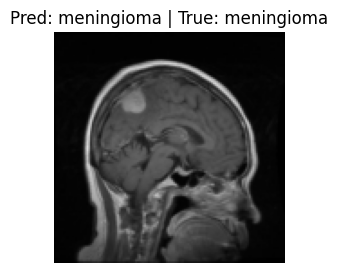

In [ ]:
import torch
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    # random index select
    ix = torch.randint(0, len(test_data), (1,)).item()

    # image + true label
    img, label = test_data[ix]
    img = img.unsqueeze(0).to(device)

    # model prediction
    output = model(img)
    probs = torch.softmax(output, dim=1).cpu().numpy()

    pred_class = train_data.classes[probs.argmax()]
    true_class = train_data.classes[label]

    # plot image
    plt.figure(figsize=(3,3))
    plt.imshow(img.squeeze(0).permute(1,2,0).cpu().numpy())
    plt.title(f"Pred: {pred_class} | True: {true_class}")
    plt.axis('off')
    plt.show()

#**Visualization**

####Loss & Accuracy Curves

The training process is visualized using accuracy and loss curves across epochs. The accuracy plot shows the performance of both training and validation data, helping to understand how well the model learns over time. The loss plot illustrates how the error decreases during training. These visualizations are useful for identifying model behavior such as convergence, underfitting, or overfitting. The plots are generated using Matplotlib with clear formatting and are saved as an image file for documentation.

/tmp/ipykernel_935/1241676914.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


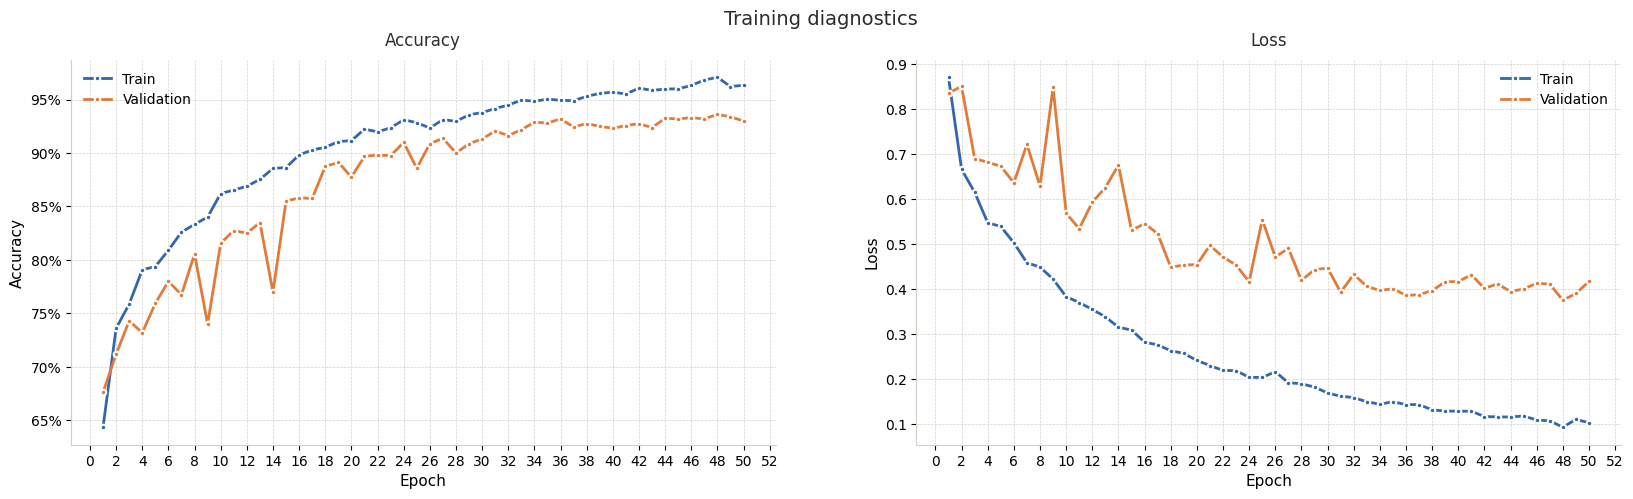

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import numpy as np

BLUE   = "#3266ad"
ORANGE = "#e07b39"
GRAY   = "#88877f"
BLACK  = "#000000"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#d3d1c7",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#d3d1c7",
    "grid.linewidth": 0.5,
    "grid.linestyle": "--",
    "xtick.color": BLACK,
    "ytick.color": BLACK,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

epochs_number = np.arange(1, epochs + 1)

fig = plt.figure(figsize=(20, 5))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.2)

# Accuracy plot
ax1 = fig.add_subplot(gs[0])
ax1.plot(
    epochs_number, train_accuracies,
    color=BLUE, lw=2, label="Train",
    marker="o", ms=4, mew=1.5, mec="white"
)
ax1.plot(
    epochs_number, val_accuracies,
    color=ORANGE, lw=2, label="Validation",
    marker="o", ms=4, mew=1.5, mec="white", linestyle="-"
)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax1.set_xlabel("Epoch", color=BLACK, fontsize=11)
ax1.set_ylabel("Accuracy", color=BLACK, fontsize=11)
ax1.set_title("Accuracy", fontsize=12, fontweight="medium", color="#2c2c2a", pad=10)
ax1.legend(frameon=False, fontsize=10)

# Loss plot
ax2 = fig.add_subplot(gs[1])
ax2.plot(
    epochs_number, train_losses,
    color=BLUE, lw=2, label="Train",
    marker="o", ms=4, mew=1.5, mec="white"
)
ax2.plot(
    epochs_number, val_losses,
    color=ORANGE, lw=2, label="Validation",
    marker="o", ms=4, mew=1.5, mec="white", linestyle="-"
)
ax2.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax2.set_xlabel("Epoch", color=BLACK, fontsize=11)
ax2.set_ylabel("Loss", color=BLACK, fontsize=11)
ax2.set_title("Loss", fontsize=12, fontweight="medium", color="#2c2c2a", pad=10)
ax2.legend(frameon=False, fontsize=10)

fig.suptitle("Training diagnostics", fontsize=14, fontweight="medium", color="#2c2c2a", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("training_curves.png", bbox_inches="tight", dpi=150)
plt.show()

####Confusion Matrix,Precision,Recall,F1-Score

The trained model is evaluated on the validation/test set by collecting the true labels and predicted labels for all samples. A confusion matrix is then generated to visualize the class-wise prediction performance. This helps identify which classes are classified correctly and where misclassifications occur. In addition, precision, recall, and F1-score are used to measure per-class performance in more detail. From the results, the model performs best on the notumor and pituitary classes, while the glioma class shows comparatively lower recall, indicating that it is the most challenging class for the model.

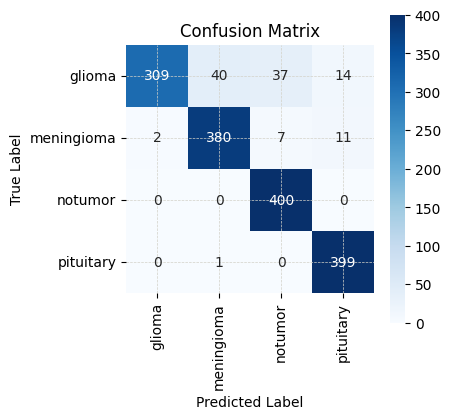

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

labels = train_data.classes

plt.figure(figsize=(4, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    square=True
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds, average='macro')
recall    = recall_score(all_labels, all_preds, average='macro')
f1        = f1_score(all_labels, all_preds, average='macro')

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.9345301487965201
Recall: 0.93
F1-score: 0.9278031445410682


In [ ]:
#Per Class Performance
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    target_names=train_data.classes,
    output_dict=True
)

print(classification_report(all_labels, all_preds, target_names=train_data.classes))

              precision    recall  f1-score   support

      glioma       0.99      0.77      0.87       400
  meningioma       0.90      0.95      0.93       400
     notumor       0.90      1.00      0.95       400
   pituitary       0.94      1.00      0.97       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



###Misclassified

Total misclassified samples: 112


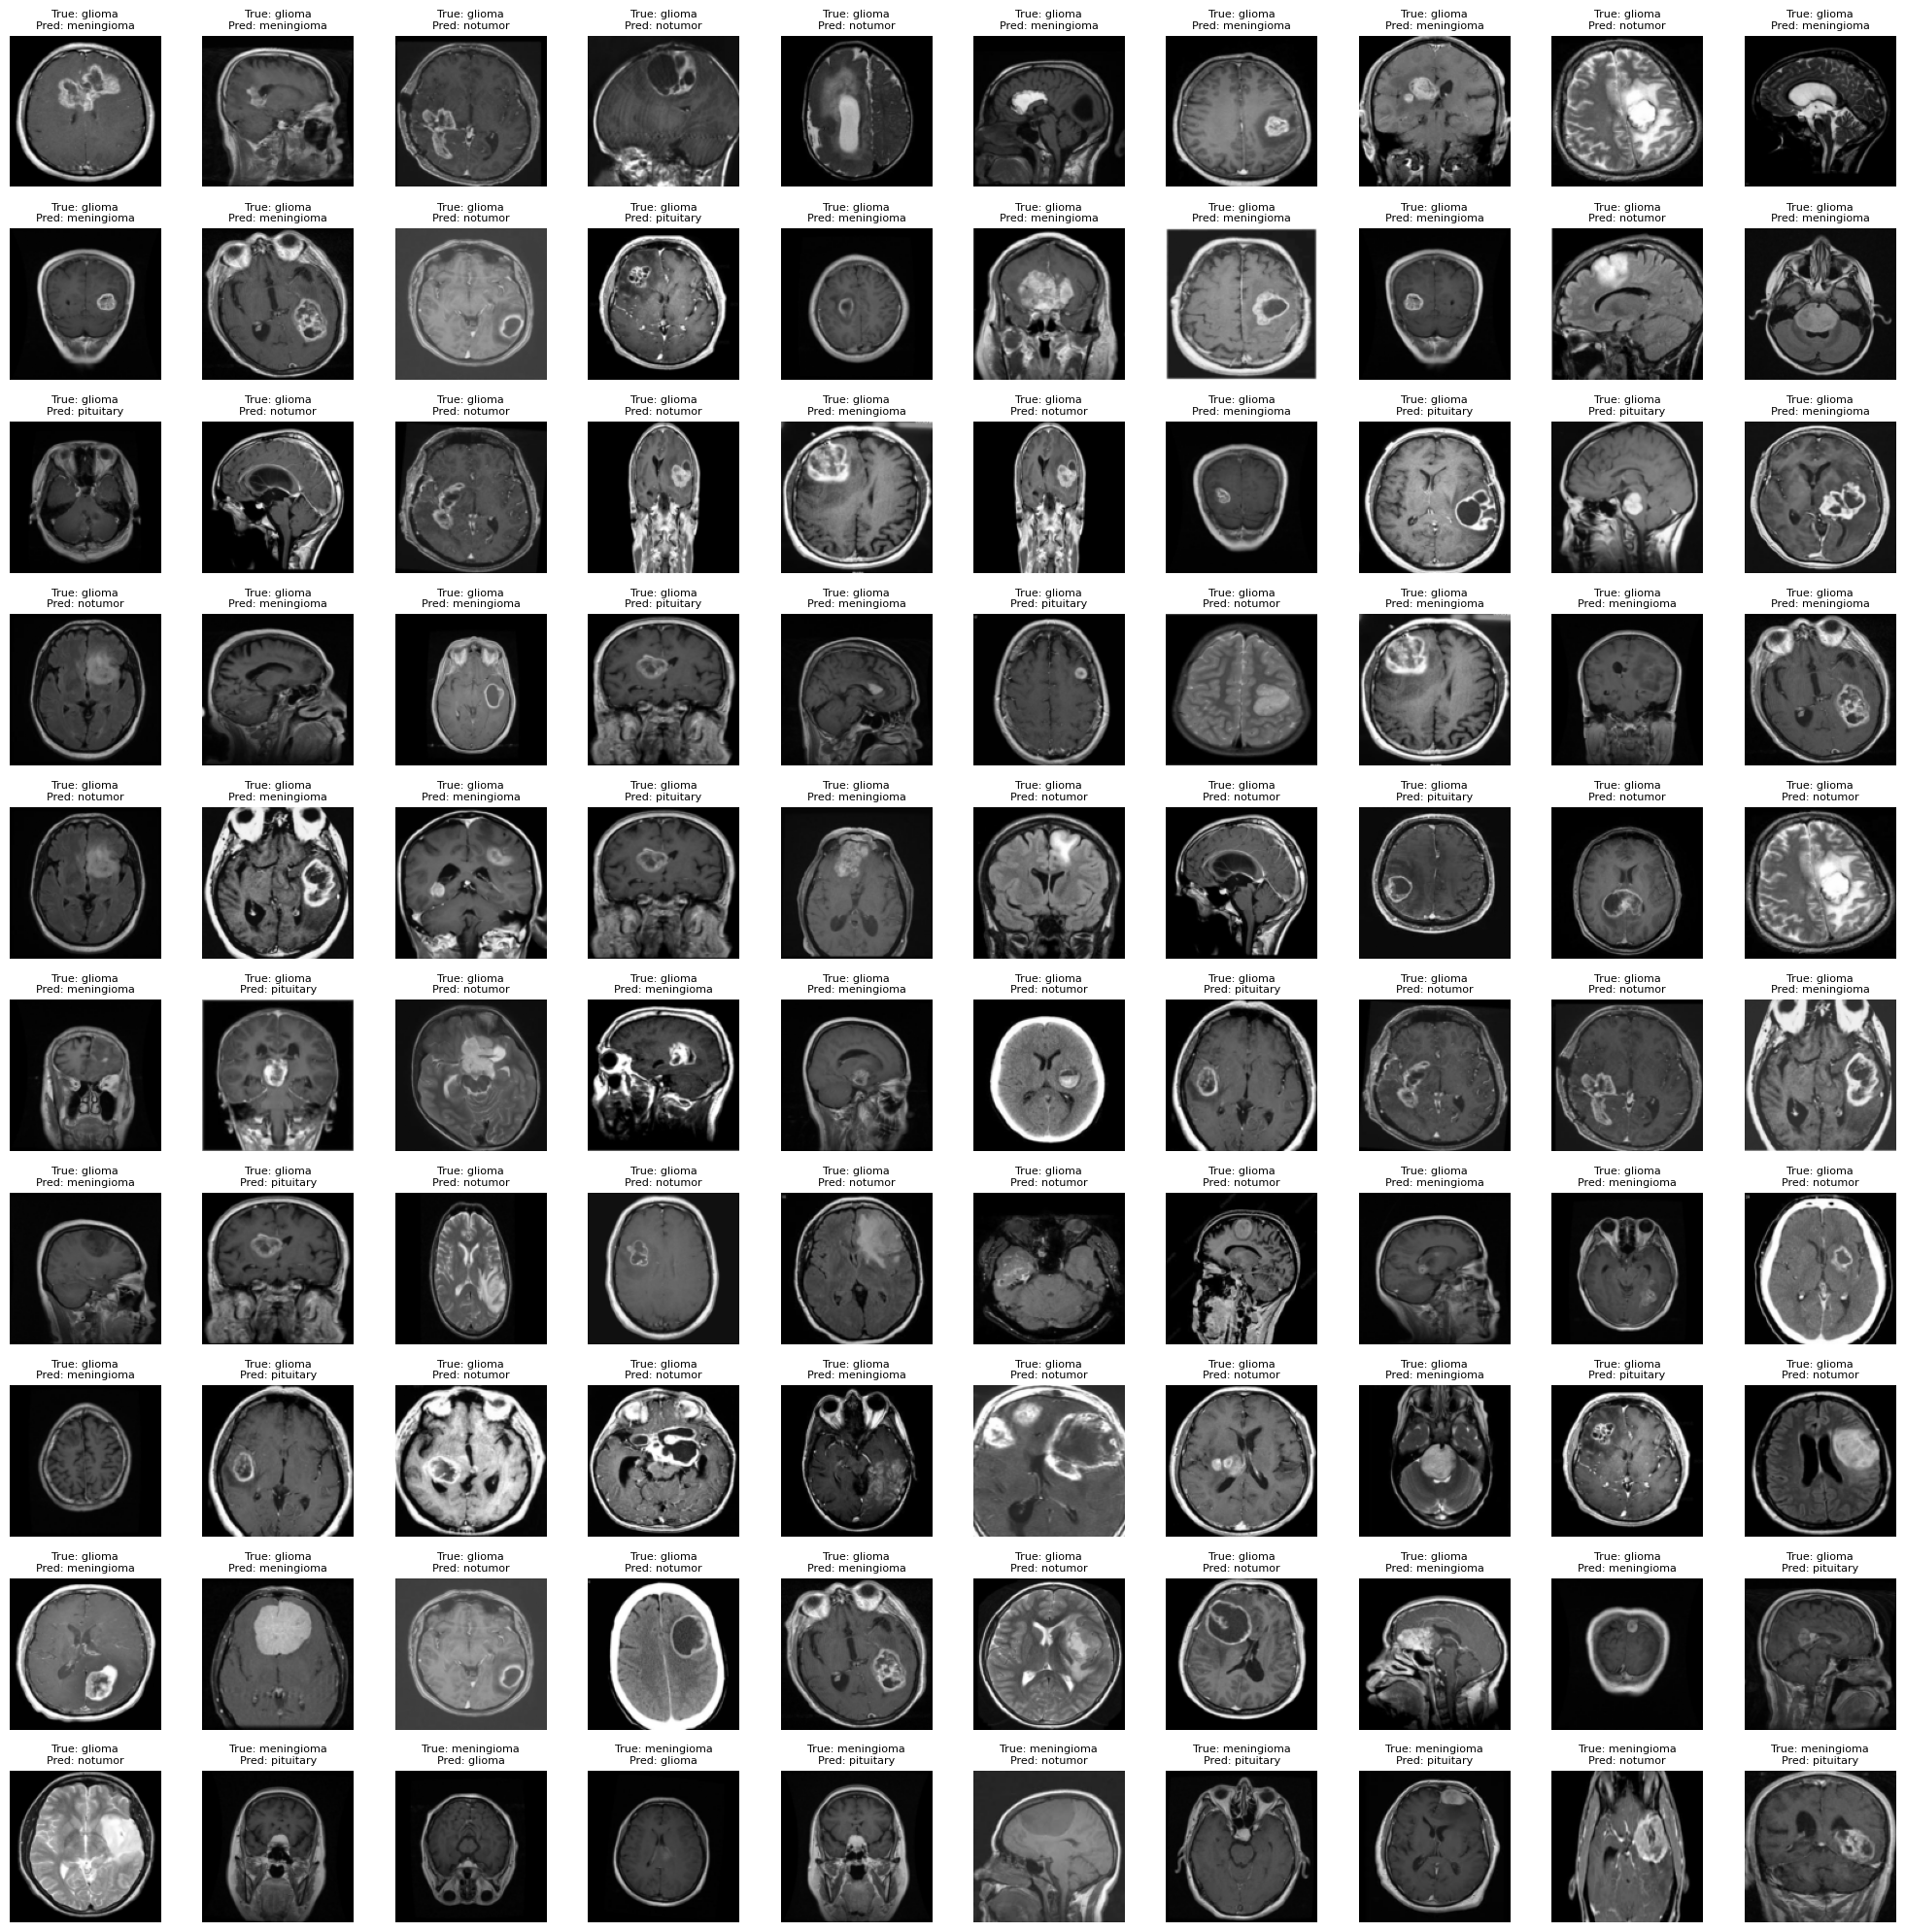

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch

class_names = train_data.classes

model.eval()
misclassified = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        for img, true, pred in zip(images, labels, preds):
            if true.item() != pred.item():
                misclassified.append((img.cpu(), true.item(), pred.item()))

print(f"Total misclassified samples: {len(misclassified)}")

num_rows = 10
num_cols = 10
num_to_show = min(num_rows * num_cols, len(misclassified))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))
axes = axes.flatten()

for idx in range(num_to_show):
    img, true, pred = misclassified[idx]
    img = img.permute(1, 2, 0).numpy()

    axes[idx].imshow(img)
    axes[idx].set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}", fontsize=8)
    axes[idx].axis('off')

for idx in range(num_to_show, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

#**Analysis & Discussion of Results**

The CNN model trained for 50 epochs with a base kernel size of 48 and a batch size of 32 demonstrates strong overall performance and good generalization capability. The training accuracy reached around 96.34%, while the validation accuracy achieved approximately 93%, showing only a small gap between them, which indicates minimal and acceptable overfitting. The loss curves also support this observation, as the training loss steadily decreased to a low value, whereas the validation loss remained slightly higher with some fluctuations, suggesting minor uncertainty but overall stable learning. According to the confusion matrix, the model performs exceptionally well on the “notumor” and “pituitary” classes with near-perfect classification, and also shows strong performance on “meningioma.” However, the model faces difficulty in correctly classifying the “glioma” class, where several samples are misclassified into other categories, likely due to feature similarity or complexity in that class. Overall, the model achieves high accuracy and reliable performance across most classes.

#**Conclusion & Future Work**

In this study, proposed CNN model trained with a batch size of 32 for 50 epochs and a base kernel size of 48 achieved strong performance in classifying brain tumor MRI images. The model reached approximately 93% validation accuracy, demonstrating good generalization with only slight overfitting. It performed exceptionally well on most classes, especially “notumor” and “pituitary,” and showed reliable performance on “meningioma.” However, the model had some difficulty distinguishing the “glioma” class, leading to a few misclassifications. Overall, the model is effective and suitable for multi-class brain tumor classification tasks, with room for further improvement.

For future improvements, several enhancements can be explored to further improve model performance. Although data augmentation has already been applied, more advanced or targeted augmentation techniques can be introduced, specifically focusing on the glioma class to reduce misclassification. Additionally, class imbalance handling or the use of weighted loss functions can help the model focus more on difficult classes. The model architecture can also be improved by experimenting with deeper networks or transfer learning approaches such as ResNet or EfficientNet, which are known to perform well on medical imaging tasks. Furthermore, hyperparameter tuning, including adjustments to learning rate scheduling and model depth, may lead to better optimization. Finally, increasing dataset diversity or incorporating external datasets could enhance the robustness and generalization capability of the model in real-world scenarios.